# Phase 2 : Analyse Exploratoire des Données (AED)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import mannwhitneyu, chi2_contingency, pointbiserialr
import warnings
warnings.filterwarnings("ignore")

* Chargement du dataset nettoyé.

In [2]:
df = pd.read_csv('../data/framingham_heart_study_clean.csv')
df.head()

,male,age,education,currentSmoker,cigsPerDay,BPMeds,prevalentStroke,prevalentHyp,diabetes,totChol,...,pulse_pressure,age_sysBP,smoke_chol,BMI_Interpret_Insuffisance ponderale,BMI_Interpret_Obesite,BMI_Interpret_Surpoids,Tension_Hypertension,Tension_Normale,heartRate_Interpret_Normale,heartRate_Interpret_Tachycardie
0,1,39,4,0,0,0,0,0,0,195.0,...,36.0,4134.0,0.0,0,0,1,0,1,1,0
1,0,46,2,0,0,0,0,0,0,250.0,...,40.0,5566.0,0.0,0,0,1,1,0,1,0
2,1,48,1,1,20,0,0,0,0,245.0,...,47.5,6120.0,4900.0,0,0,1,1,0,1,0
3,0,61,3,1,30,0,0,1,0,225.0,...,55.0,9150.0,6750.0,0,0,1,1,0,1,0
4,0,46,3,1,23,0,0,0,0,285.0,...,46.0,5980.0,6555.0,0,0,0,1,0,1,0


* Définition des listes de variables continues et catégorielles.

In [3]:
var_continues = ['age', 'cigsPerDay', 'totChol', 'sysBP', 'diaBP', 'BMI',
                 'heartRate', 'glucose', 'risk_score', 'pulse_pressure']

var_cat = ['male', 'education', 'currentSmoker', 'BPMeds', 'prevalentStroke',
           'prevalentHyp', 'diabetes',
           'BMI_Interpret_Insuffisance ponderale', 'BMI_Interpret_Obesite', 'BMI_Interpret_Surpoids',
           'Tension_Hypertension', 'Tension_Normale',
           'heartRate_Interpret_Normale', 'heartRate_Interpret_Tachycardie',
           'TenYearCHD']

1. Analyse univariée :

* Histogrammes pour les variables continues.

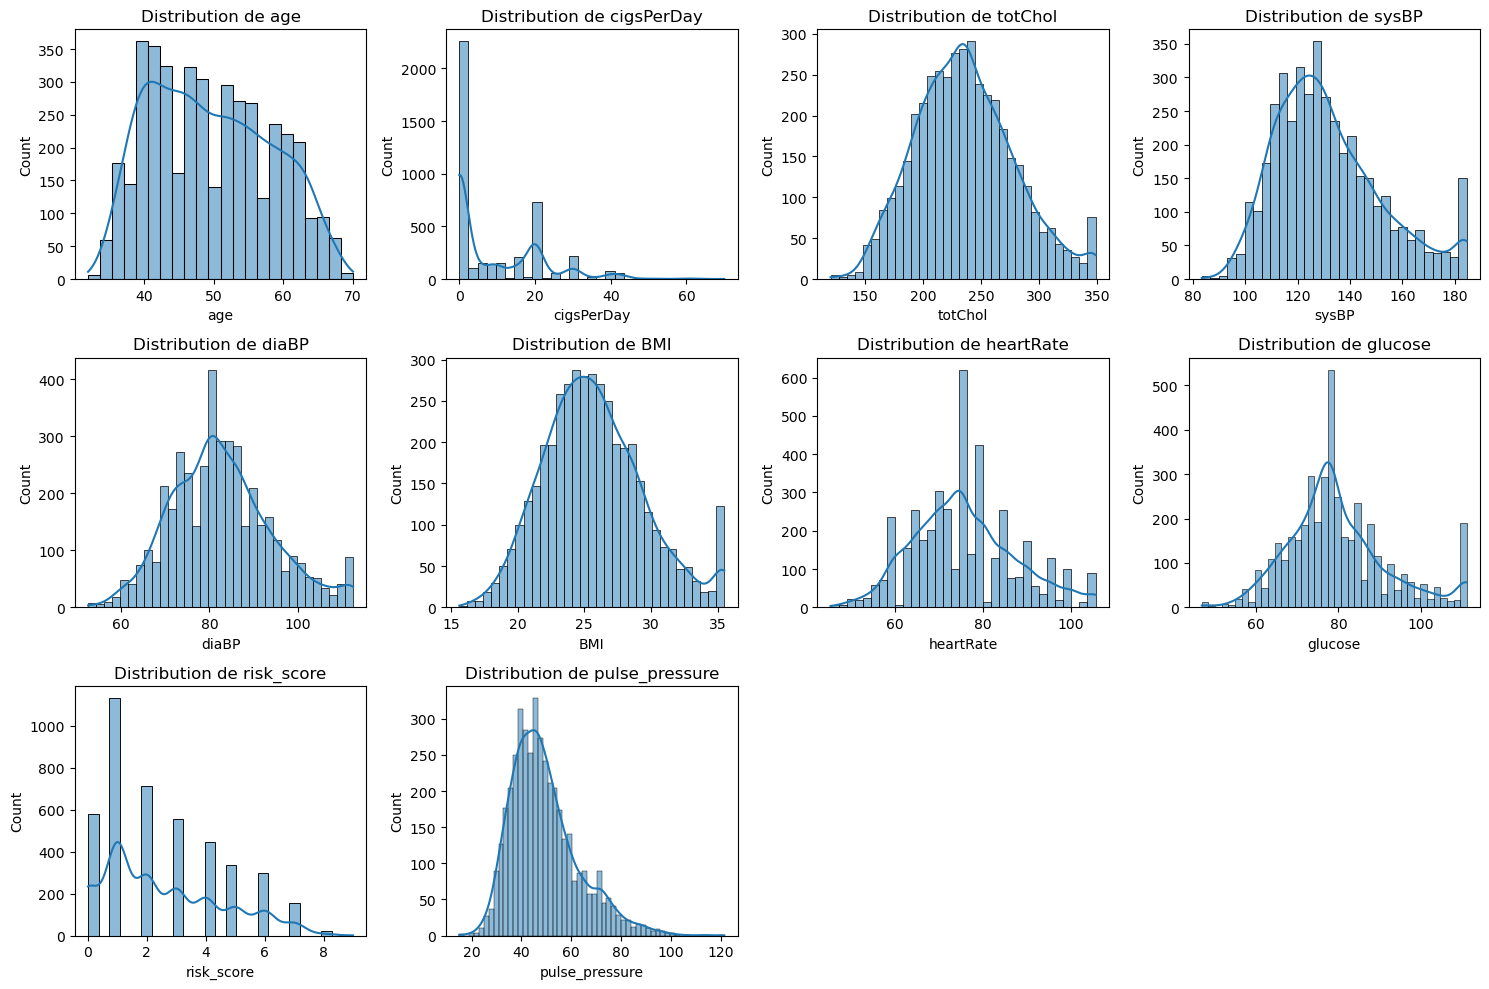

In [4]:
plt.figure(figsize=(15, 10))
for i, feature in enumerate(var_continues):
    plt.subplot(3, 4, i + 1)
    sns.histplot(df[feature], kde=True)
    plt.title(f"Distribution de {feature}")
plt.tight_layout()
plt.show()

2. Analyse bivariée :

* Relation entre la variable cible et les variables continues (boxplots).

ValueError: num must be an integer with 1 <= num <= 9, not 10

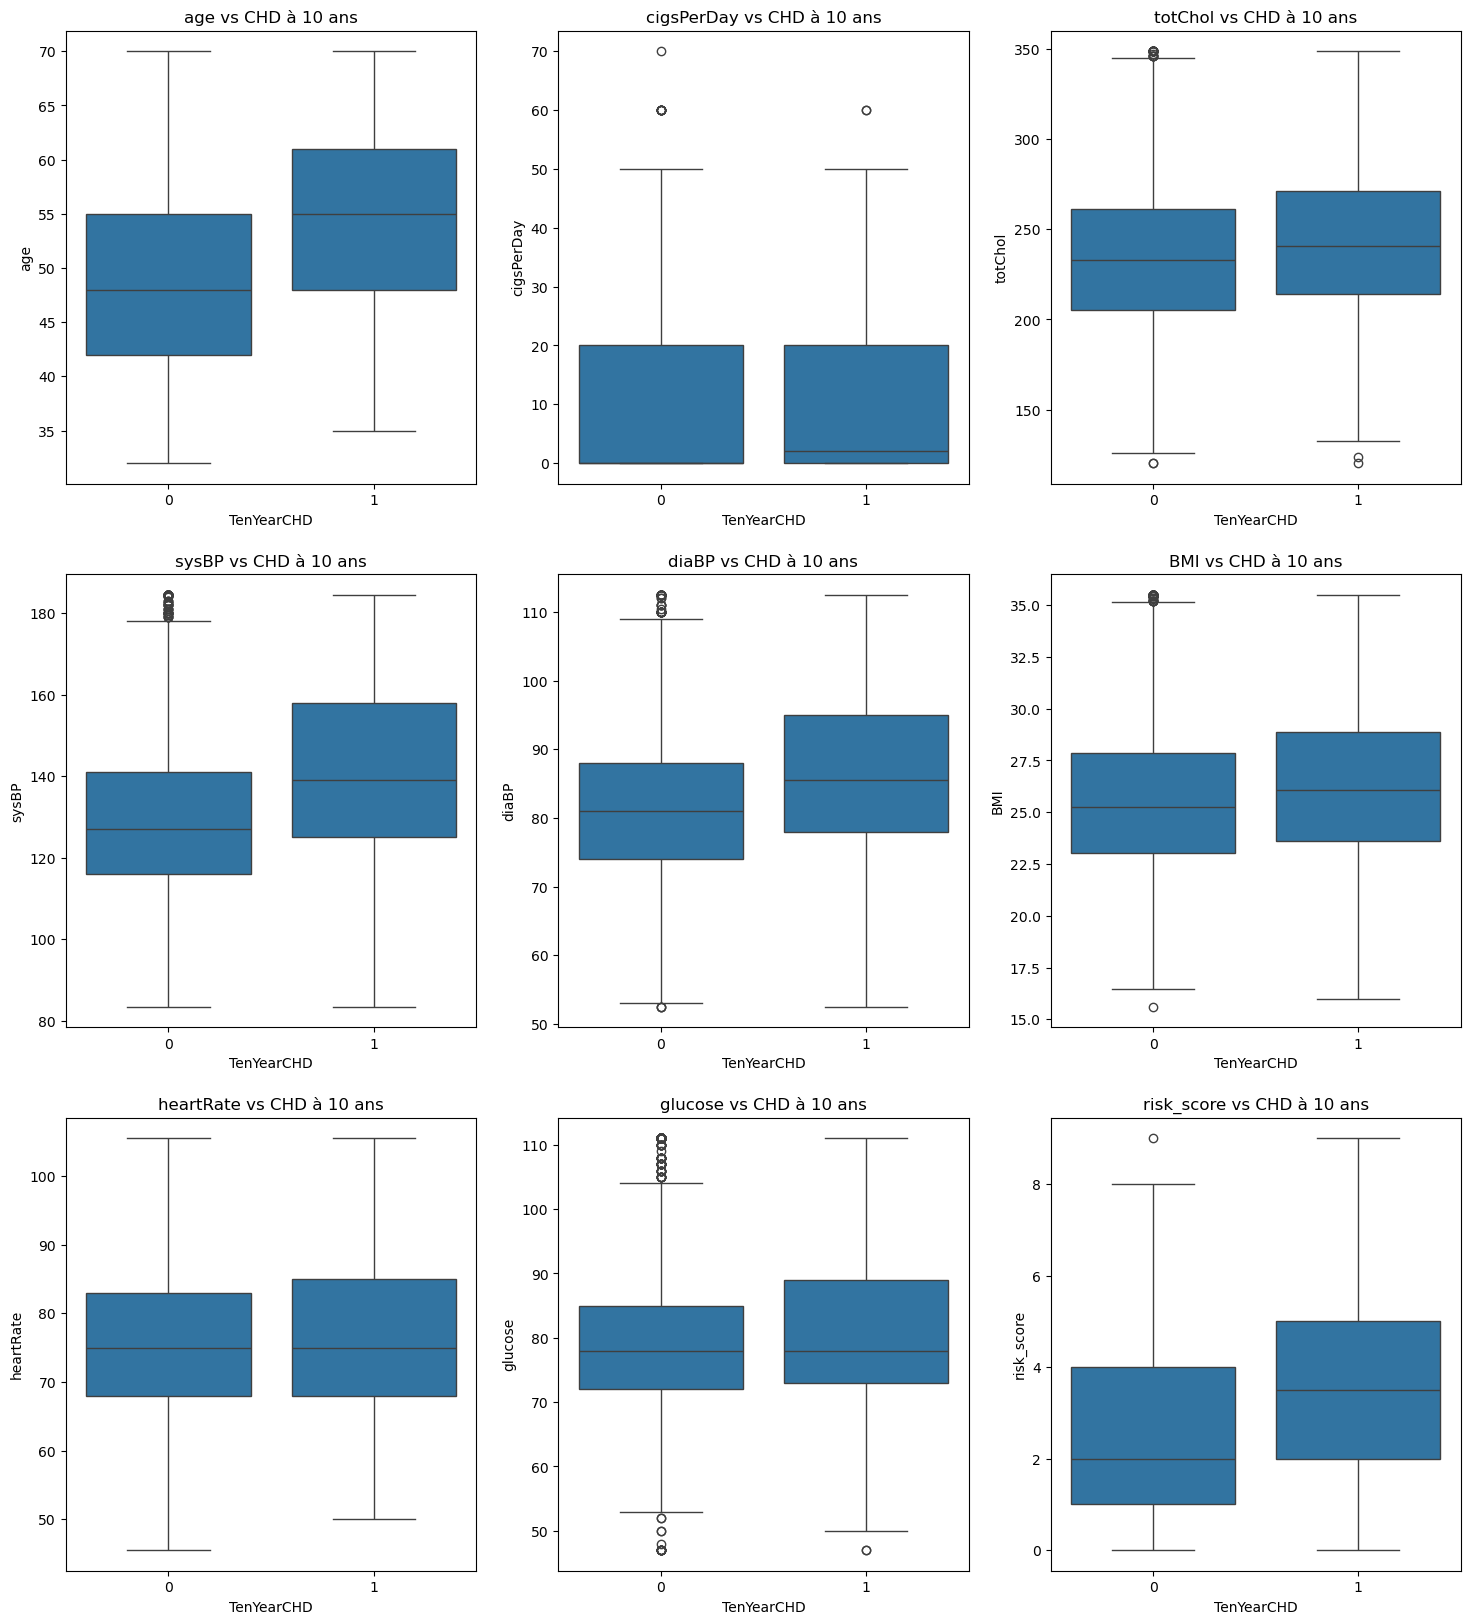

In [15]:
plt.figure(figsize=(18, 5 *4))

for i, col in enumerate(var_continues):
    plt.subplot(3, 3, i + 1)
    sns.boxplot(x="TenYearCHD", y=col, data=df)
    plt.title(f"{col} vs CHD à 10 ans")

plt.tight_layout()
plt.show()

* Relation entre la variable cible et les variables catégorielles (tableaux de contingence et diagrammes groupés).


Tableau de contingence : male vs TenYearCHD
TenYearCHD     0    1
male                 
0           2119  301
1           1477  343

Tableau de contingence : education vs TenYearCHD
TenYearCHD     0    1
education            
1           1486  339
2           1106  147
3            601   88
4            403   70

Tableau de contingence : currentSmoker vs TenYearCHD
TenYearCHD        0    1
currentSmoker           
0              1834  311
1              1762  333

Tableau de contingence : BPMeds vs TenYearCHD
TenYearCHD     0    1
BPMeds               
0           3513  603
1             83   41

Tableau de contingence : prevalentStroke vs TenYearCHD
TenYearCHD          0    1
prevalentStroke           
0                3582  633
1                  14   11

Tableau de contingence : prevalentHyp vs TenYearCHD
TenYearCHD       0    1
prevalentHyp           
0             2604  319
1              992  325

Tableau de contingence : diabetes vs TenYearCHD
TenYearCHD     0    1
diabetes    

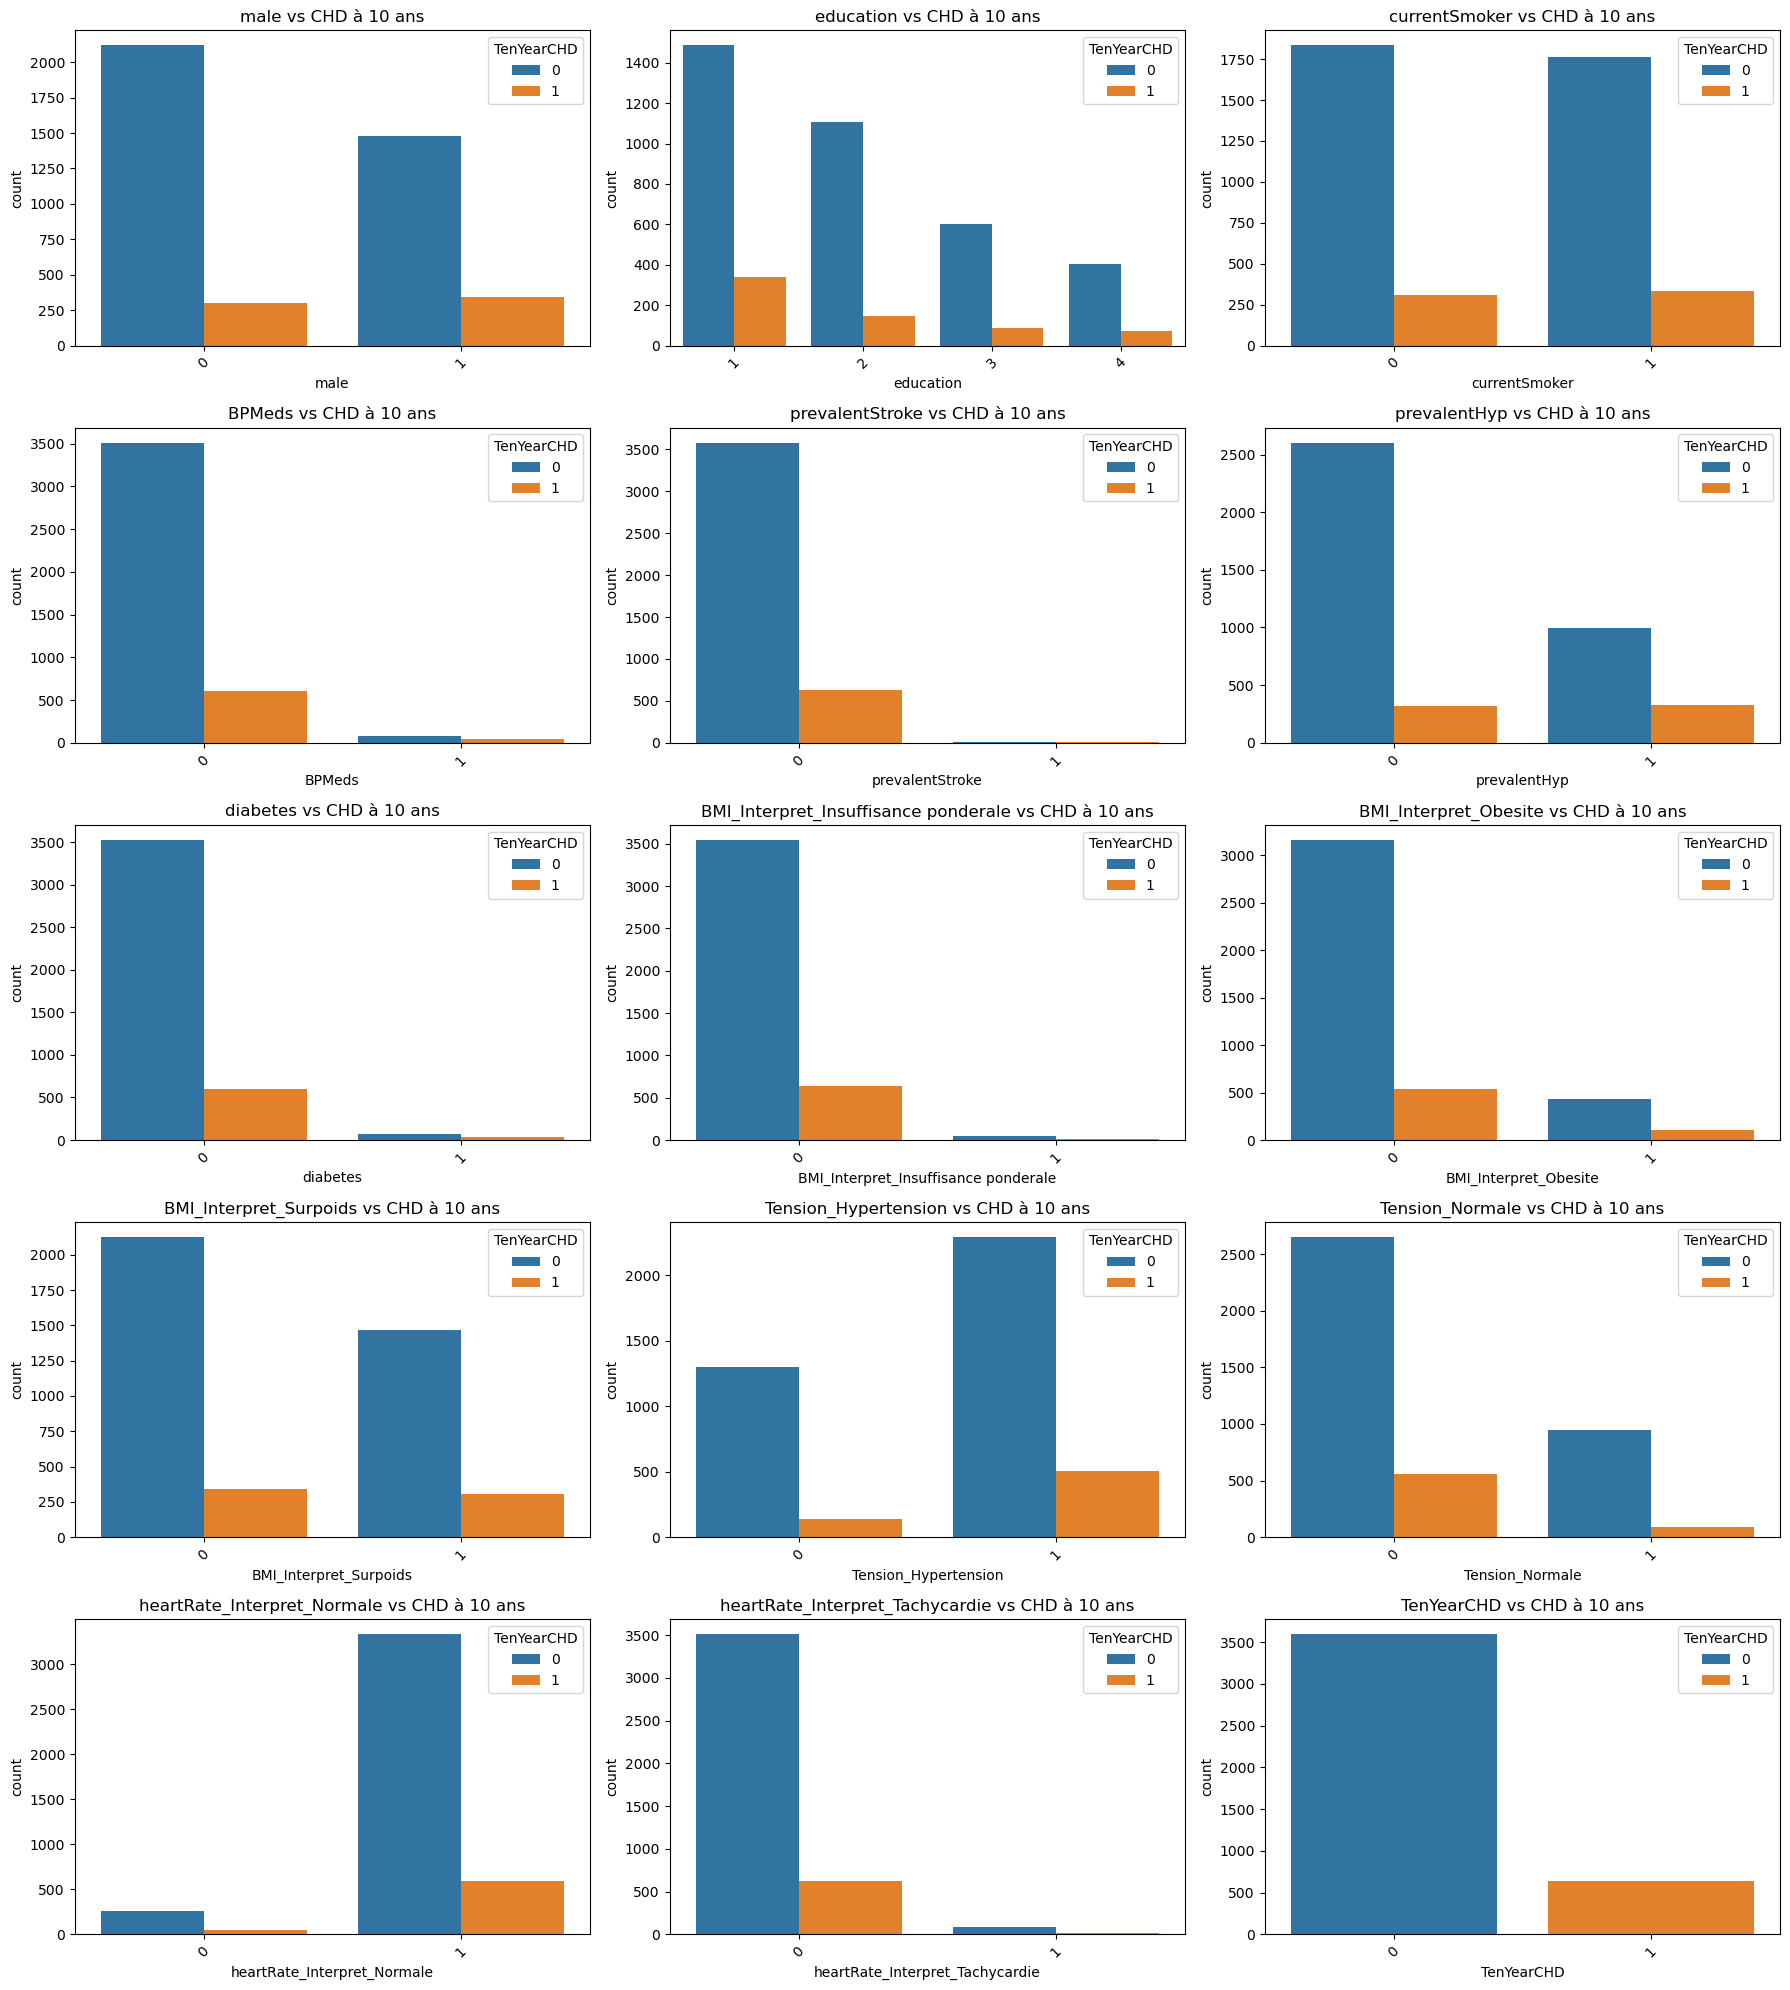

In [18]:
plt.figure(figsize=(18, 5 *4))
for i, col in enumerate(var_cat):
    
    # Tableau de contingence (affiché dans la console)
    print(f"\nTableau de contingence : {col} vs TenYearCHD")
    print(pd.crosstab(df[col], df["TenYearCHD"]))
    
    # Subplot
    plt.subplot(5, 3, i + 1)
    sns.countplot(x=col, hue="TenYearCHD", data=df)
    plt.title(f"{col} vs CHD à 10 ans")
    plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

* Pairplot sur les variables les plus corrélées à la cible.

Le pairplot est limité aux variables continues les plus corrélées à `TenYearCHD` pour rester lisible. Représenter l'ensemble des variables encodées produirait un graphique illisible.

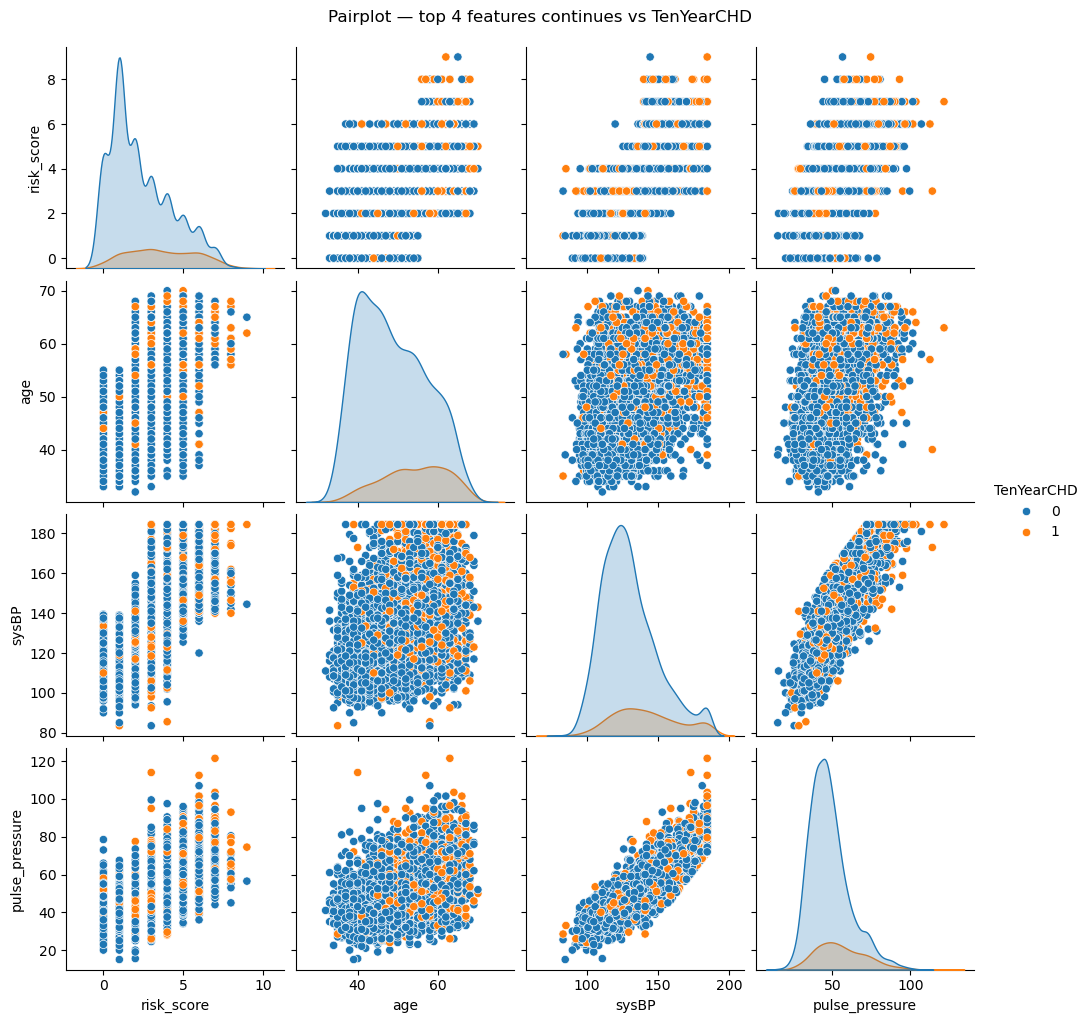

In [7]:
top_cont = df[var_continues + ['TenYearCHD']].corrwith(df['TenYearCHD']).abs().sort_values(ascending=False).head(5).index.tolist()
if 'TenYearCHD' not in top_cont:
    top_cont.append('TenYearCHD')

sns.pairplot(df[top_cont], hue='TenYearCHD')
plt.suptitle("Pairplot — top 4 features continues vs TenYearCHD", y=1.02)
plt.show()

3. Matrice de corrélation :

* Calcul et visualisation (heatmap).

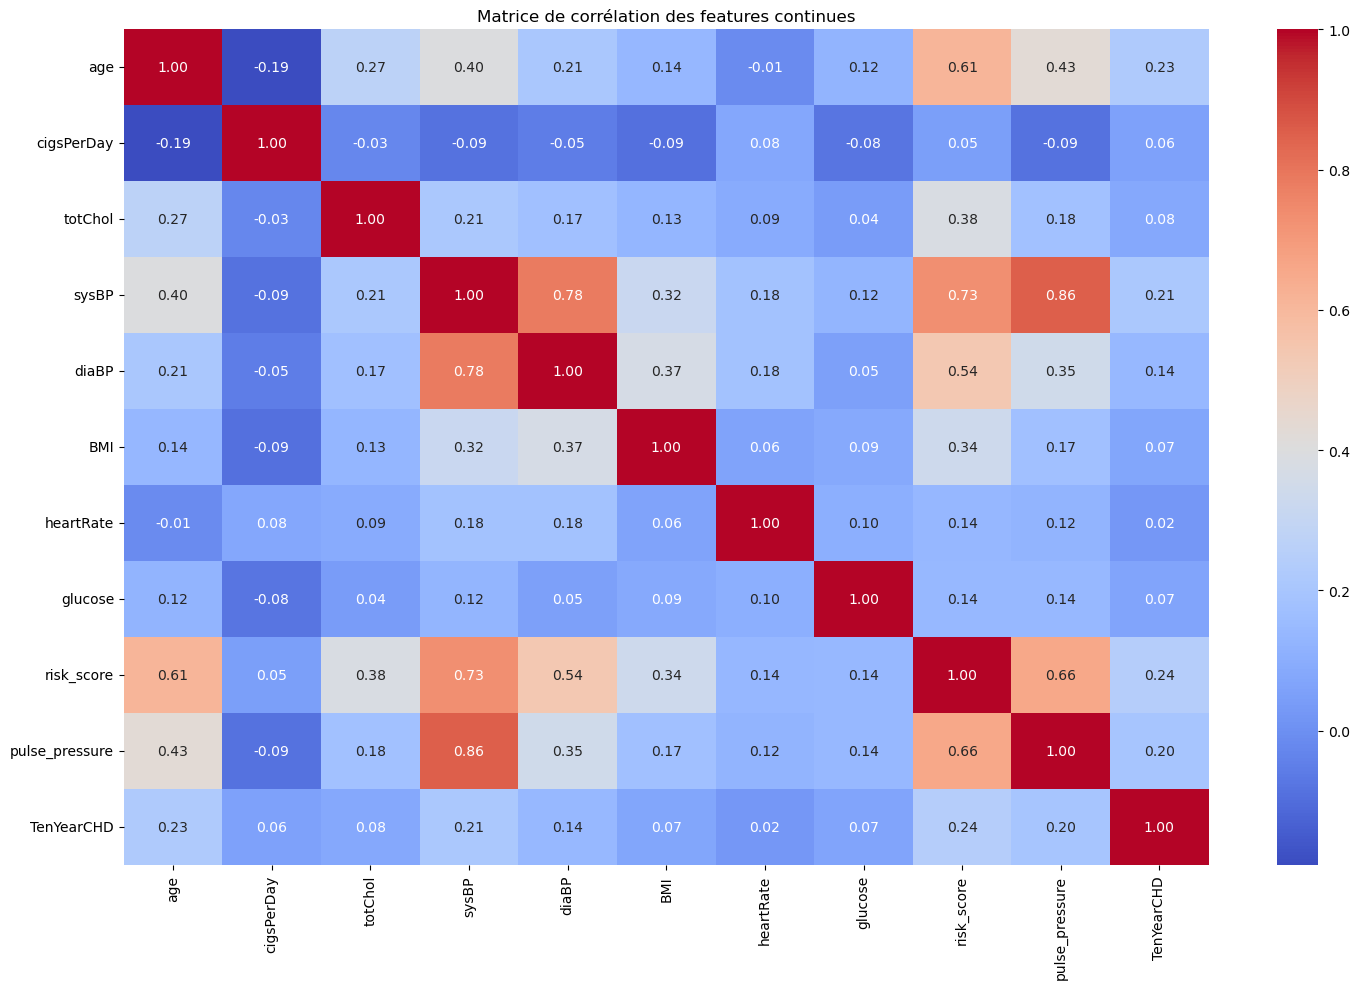

In [8]:
col_corr = var_continues + ["TenYearCHD"]
cor = df[col_corr].corr()

plt.figure(figsize=(15, 10))
sns.heatmap(cor, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Matrice de corrélation des features continues')
plt.tight_layout()
plt.show()

* Identification des corrélations fortes avec la cible et discussion sur la multicolinéarité.

In [9]:
corr_target = cor['TenYearCHD'].abs().sort_values(ascending=False)
top_4_corr_features = corr_target.head(5).index.tolist()
print("Variables les plus corrélées à TenYearCHD :")
print(corr_target.head(5))

Variables les plus corrélées à TenYearCHD :
TenYearCHD        1.000000
risk_score        0.241121
age               0.225408
sysBP             0.209623
pulse_pressure    0.198932
Name: TenYearCHD, dtype: float64


On remarque une forte colinéarité entre `age_sysBP` et `sysBP` d'une part, et entre `risk_score` et plusieurs variables individuelles d'autre part. Ces redondances seront prises en compte lors de la sélection de features en phase de modélisation.

* Test du Chi-deux pour les variables catégorielles.

Le test du Chi-deux permet de mesurer l'association entre chaque variable catégorielle et la variable cible. Un p-value inférieur à 0.05 indique une association statistiquement significative.

In [10]:
cat_cols = [c for c in var_cat if c != 'TenYearCHD']
results = []

for col in cat_cols:
    table = pd.crosstab(df[col], df["TenYearCHD"])
    chi2, p, dof, expected = chi2_contingency(table)
    results.append({
        "Variable": col,
        "Chi2": round(chi2, 3),
        "p-value": round(p, 4),
        "Significatif (p<0.05)": "Oui" if p < 0.05 else "Non"
    })

results_df = pd.DataFrame(results)
print(results_df.to_string(index=False))

                            Variable    Chi2  p-value Significatif (p<0.05)
                                male  32.618   0.0000                   Oui
                           education  31.052   0.0000                   Oui
                       currentSmoker   1.497   0.2211                   Non
                              BPMeds  30.273   0.0000                   Oui
                     prevalentStroke  14.034   0.0002                   Oui
                        prevalentHyp 132.456   0.0000                   Oui
                            diabetes  38.482   0.0000                   Oui
BMI_Interpret_Insuffisance ponderale   0.003   0.9533                   Non
               BMI_Interpret_Obesite   8.452   0.0036                   Oui
              BMI_Interpret_Surpoids   8.725   0.0031                   Oui
                Tension_Hypertension  50.476   0.0000                   Oui
                     Tension_Normale  45.134   0.0000                   Oui
         hea

* Corrélation absolue de toutes les features avec la variable cible.

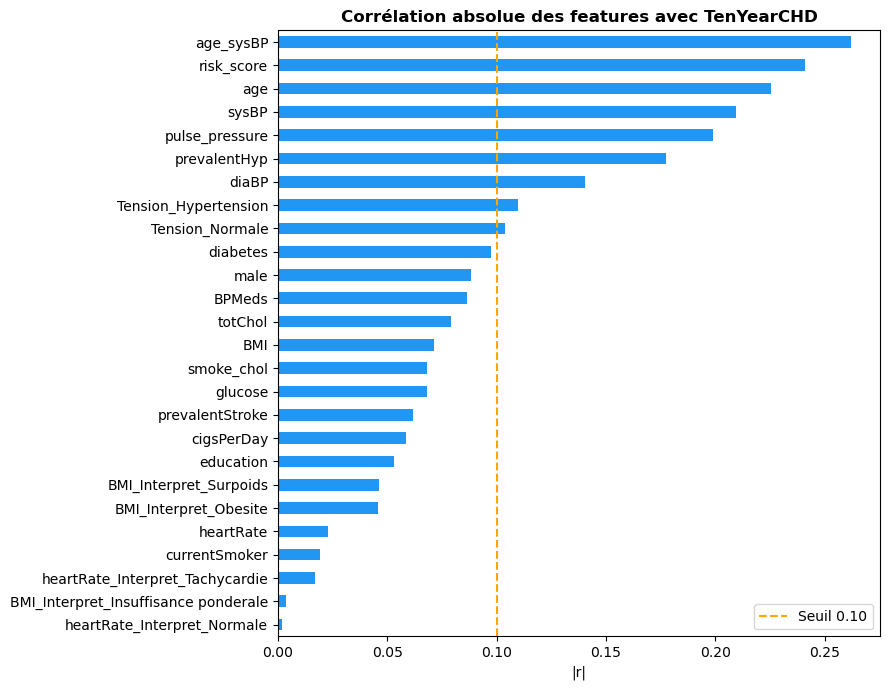

In [11]:
top_features = df.drop('TenYearCHD', axis=1).corrwith(df['TenYearCHD']).abs().sort_values(ascending=True)

plt.figure(figsize=(9, 7))
top_features.plot(kind='barh', color='#2196F3')
plt.axvline(0.1, color='orange', linestyle='--', label='Seuil 0.10')
plt.title("Corrélation absolue des features avec TenYearCHD", fontweight='bold')
plt.xlabel("|r|")
plt.legend()
plt.tight_layout()
plt.show()

* Sélection indicative des features et export.

Les 11 features présentant la corrélation absolue la plus élevée avec `TenYearCHD` sont sélectionnées ici à titre indicatif, sur l'ensemble du dataset, pour réduire la dimensionnalité avant la modélisation.
**Remarque importante** : cette sélection sur l'ensemble du dataset est un filtre exploratoire. Dans le notebook de modélisation, la sélection finale des features se fera uniquement sur le jeu d'entraînement (`x_train`) afin d'éviter toute fuite d'information (data leakage).

In [12]:
important_features = top_features.sort_values(ascending=False).head(11).index.tolist()
important_features.append("TenYearCHD")

print("Features sélectionnées :")
print(important_features)

df[important_features].to_csv("../data/top_features.csv", index=False)

Features sélectionnées :
['age_sysBP', 'risk_score', 'age', 'sysBP', 'pulse_pressure', 'prevalentHyp', 'diaBP', 'Tension_Hypertension', 'Tension_Normale', 'diabetes', 'male', 'TenYearCHD']
